# Round 5 Price Path Exploration

This notebook loads the Round 5 price data from `datasets/round5` and visualizes the mid-price paths for products across days 2, 3, and 4.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

base_path = Path("../datasets/round5")
price_files = {
    2: "prices_round_5_day_2.csv",
    3: "prices_round_5_day_3.csv",
    4: "prices_round_5_day_4.csv",
}

all_prices = []
for day, file_name in price_files.items():
    file_path = base_path / file_name
    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = df["timestamp"].astype(int)
    all_prices.append(df)

all_prices = pd.concat(all_prices, ignore_index=True)

all_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,PEBBLES_L,9994,13,9992.0,21.0,NaN,NaN,10006,13,10008.0,21.0,NaN,NaN,10000.0,0.0
1,2,0,SNACKPACK_RASPBERRY,9992,36,9990.0,45.0,NaN,NaN,10008,36,10010.0,45.0,NaN,NaN,10000.0,0.0
2,2,0,UV_VISOR_RED,9994,22,9992.0,26.0,NaN,NaN,10006,22,10008.0,26.0,NaN,NaN,10000.0,0.0
3,2,0,PEBBLES_M,9994,13,9992.0,21.0,NaN,NaN,10006,13,10008.0,21.0,NaN,NaN,10000.0,0.0
4,2,0,GALAXY_SOUNDS_DARK_MATTER,9994,22,9992.0,26.0,NaN,NaN,10006,22,10008.0,26.0,NaN,NaN,10000.0,0.0


In [16]:
print("Loaded price data shape:", all_prices.shape)
print("Days in dataset:", sorted(all_prices["day"].unique()))
print("Unique products:", all_prices["product"].nunique())
print("Rows per day:")
print(all_prices.groupby("day")["product"].nunique())

Loaded price data shape: (1500000, 17)
Days in dataset: [np.int64(2), np.int64(3), np.int64(4)]
Unique products: 50
Rows per day:
day
2    50
3    50
4    50
Name: product, dtype: int64


## Price Path Summary

We will plot the mid-price paths for all products, then highlight a small set of products that show variation across the available days.

In [17]:
# Choose a sample of products to highlight
product_volatility = (
    all_prices[all_prices["day"] == 2]
    .groupby("product")["mid_price"]
    .std()
    .sort_values(ascending=False)
)
selected_products = product_volatility.head(8).index.tolist()
selected_products

['PEBBLES_XL',
 'MICROCHIP_SQUARE',
 'UV_VISOR_YELLOW',
 'OXYGEN_SHAKE_GARLIC',
 'PEBBLES_XS',
 'OXYGEN_SHAKE_EVENING_BREATH',
 'SLEEP_POD_POLYESTER',
 'GALAXY_SOUNDS_BLACK_HOLES']

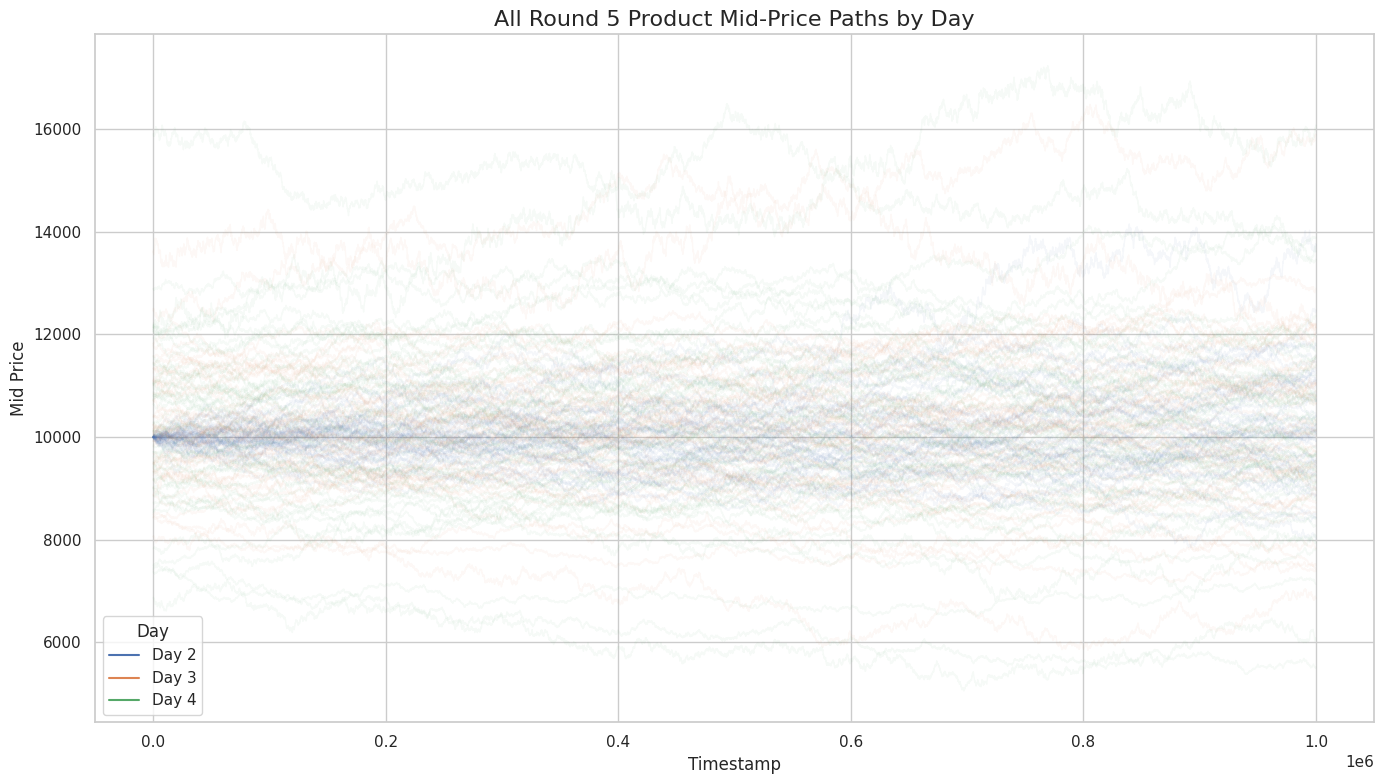

In [18]:
fig, ax = plt.subplots(figsize=(14, 8))
for day in sorted(price_files):
    day_df = all_prices[all_prices["day"] == day]
    for product, group in day_df.groupby("product"):
        ax.plot(
            group["timestamp"],
            group["mid_price"],
            color=f"C{day - 2}",
            alpha=0.05,
            linewidth=1,
        )

# Add a single legend line per day
for day in sorted(price_files):
    ax.plot([], [], color=f"C{day - 2}", label=f"Day {day}")

ax.set_title("All Round 5 Product Mid-Price Paths by Day", fontsize=16)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Mid Price")
ax.legend(title="Day")
plt.tight_layout()
plt.show()

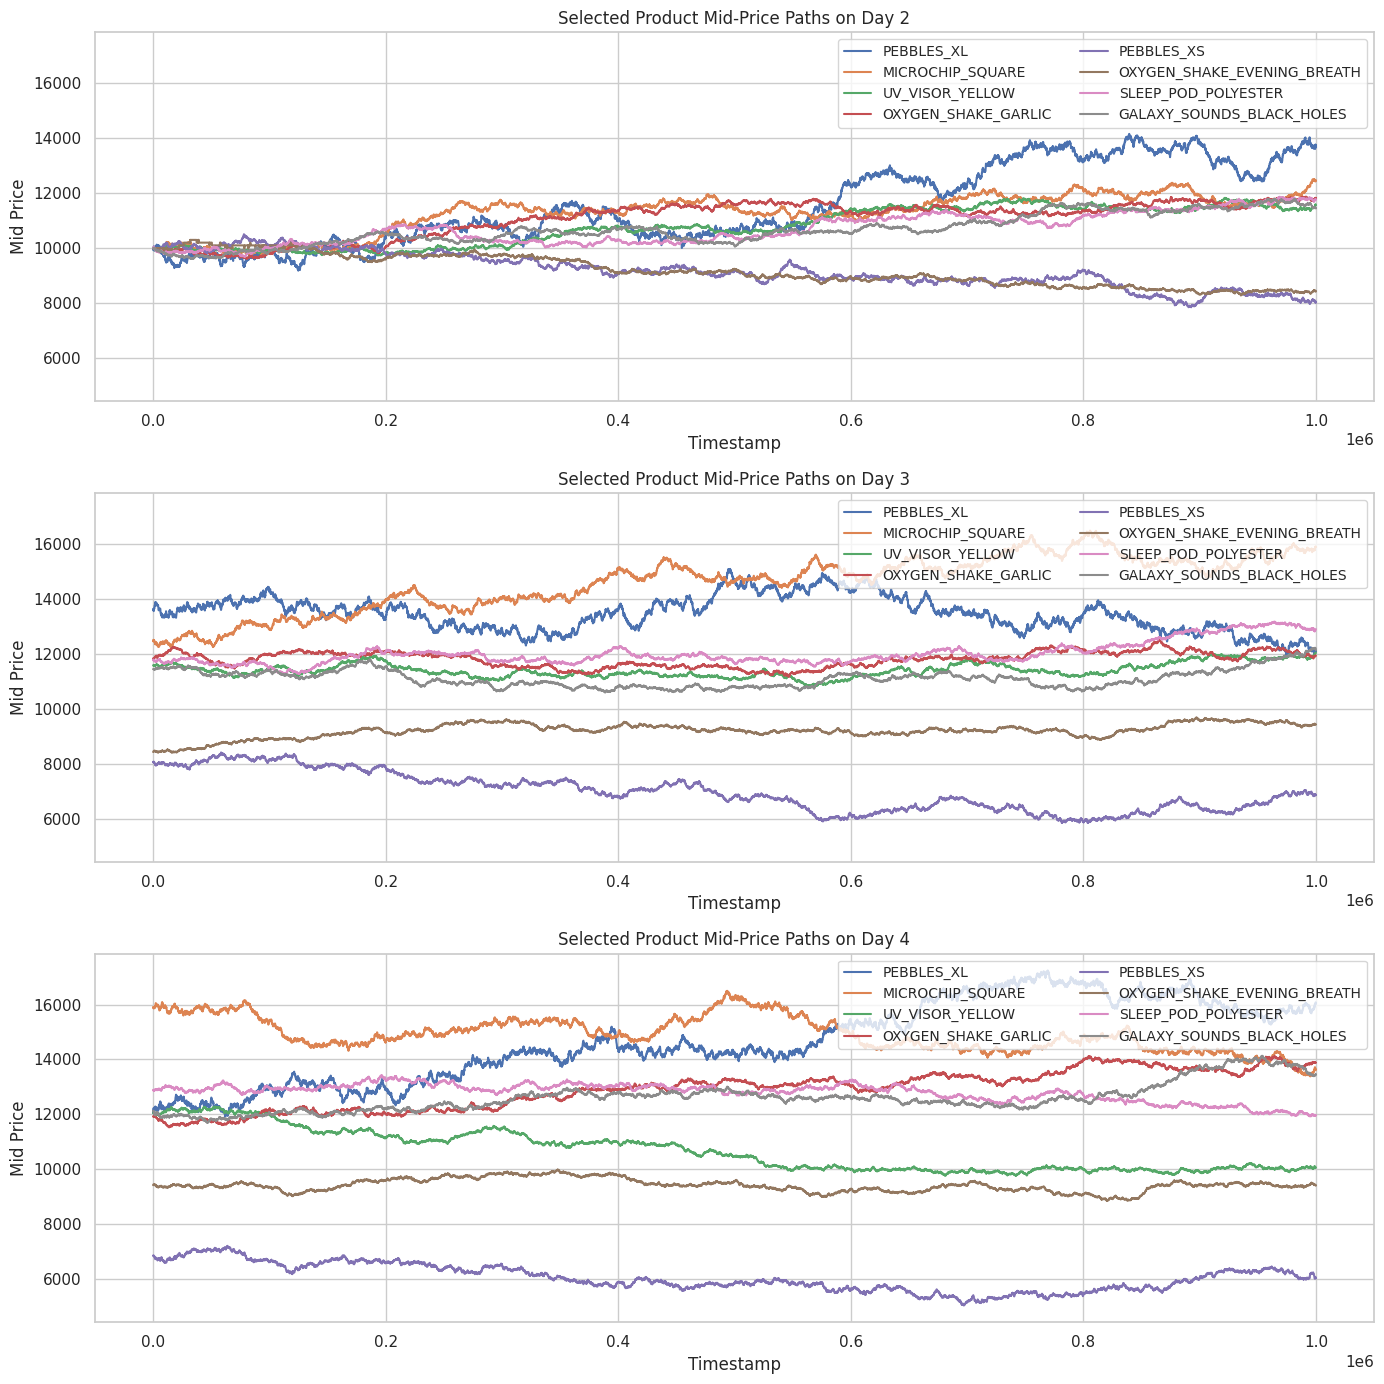

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharey=True)
for idx, day in enumerate(sorted(price_files)):
    ax = axes[idx]
    day_df = all_prices[all_prices["day"] == day]
    for product in selected_products:
        product_df = day_df[day_df["product"] == product].sort_values("timestamp")
        ax.plot(product_df["timestamp"], product_df["mid_price"], label=product)
    ax.set_title(f"Selected Product Mid-Price Paths on Day {day}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Mid Price")
    ax.legend(loc="upper right", fontsize="small", ncol=2)

plt.tight_layout()
plt.show()

## Behavior Classification by Product

Now we build features from the Round 5 price paths and classify each product-day into behavior buckets:
- `directional` if the path shows a strong persistent trend,
- `mean_reverting` if it tends to oscillate around its own average,
- `mixed` when neither signal is dominant.

In [20]:
product_metrics = []
for (day, product), group in all_prices.groupby(["day", "product"]):
    group = group.sort_values("timestamp")
    prices = group["mid_price"].astype(float)
    times = group["timestamp"].astype(float)

    if len(prices) < 2:
        continue

    time_norm = (times - times.min()) / (times.max() - times.min())
    slope, intercept = np.polyfit(time_norm, prices, 1)

    first_price = prices.iloc[0]
    last_price = prices.iloc[-1]
    avg_price = prices.mean()
    total_return = (last_price - first_price) / avg_price
    price_range = (prices.max() - prices.min()) / avg_price
    volatility = prices.diff().dropna().std()
    ar1 = prices.autocorr(lag=1)
    mean_dev = (prices - avg_price).abs().mean() / avg_price

    lag_prices = prices.shift(1)
    diff_prices = prices.diff()
    valid = lag_prices.notna() & diff_prices.notna()
    if valid.sum() > 2:
        mean_reversion_coef = np.polyfit((avg_price - lag_prices[valid]), diff_prices[valid], 1)[0]
    else:
        mean_reversion_coef = 0.0

    product_metrics.append(
        {
            "day": day,
            "product": product,
            "trend_slope": slope,
            "trend_slope_norm": slope / avg_price,
            "total_return": total_return,
            "price_range": price_range,
            "volatility": volatility,
            "ar1": ar1 if not np.isnan(ar1) else 0.0,
            "mean_deviation": mean_dev,
            "mean_reversion_coefficient": mean_reversion_coef,
        }
    )

metrics = pd.DataFrame(product_metrics)
metrics.head()

,day,product,trend_slope,trend_slope_norm,total_return,price_range,volatility,ar1,mean_deviation,mean_reversion_coefficient
0,2,GALAXY_SOUNDS_BLACK_HOLES,1778.423600,0.166511,0.135434,0.204391,10.597998,0.999820,0.042232,0.000160
1,2,GALAXY_SOUNDS_DARK_MATTER,742.086148,0.073387,0.041238,0.106904,10.067367,0.999191,0.021276,0.000745
2,2,GALAXY_SOUNDS_PLANETARY_RINGS,358.427204,0.035795,0.124735,0.202332,10.157218,0.999777,0.041377,-0.000107
3,2,GALAXY_SOUNDS_SOLAR_FLAMES,1041.791269,0.093892,0.121264,0.192238,11.116588,0.999750,0.035488,0.000481
4,2,GALAXY_SOUNDS_SOLAR_WINDS,-873.188622,-0.086741,-0.041375,0.166094,10.231221,0.999626,0.029355,0.000292


In [21]:
# Aggregate behavior across days so each product is treated as a single object.
product_summary = (
    metrics.groupby("product")
    .agg(
        mean_trend_slope_norm=("trend_slope_norm", "mean"),
        mean_total_return=("total_return", "mean"),
        mean_price_range=("price_range", "mean"),
        mean_volatility=("volatility", "mean"),
        mean_ar1=("ar1", "mean"),
        mean_mean_reversion_coefficient=("mean_reversion_coefficient", "mean"),
        day_count=("day", "nunique"),
    )
    .reset_index()
)

# Use product-level thresholds so bucket totals sum to the number of unique products.
slope_threshold = product_summary["mean_trend_slope_norm"].abs().quantile(0.75)
return_threshold = product_summary["mean_total_return"].abs().quantile(0.75)
mean_reversion_threshold = product_summary["mean_mean_reversion_coefficient"].quantile(0.65)


def classify_behavior(row):
    if abs(row["mean_trend_slope_norm"]) >= 1.5 * slope_threshold or abs(row["mean_total_return"]) >= 1.5 * return_threshold:
        return "directional"
    if row["mean_mean_reversion_coefficient"] >= mean_reversion_threshold and abs(row["mean_trend_slope_norm"]) < slope_threshold:
        return "mean_reverting"
    if abs(row["mean_ar1"]) < 0.05 and row["mean_price_range"] < 0.15:
        return "mean_reverting"
    return "mixed"

product_summary["behavior"] = product_summary.apply(classify_behavior, axis=1)
print("Total products:", product_summary.shape[0])
product_summary.groupby("behavior").size().reset_index(name="count")

Total products: 50


,behavior,count
0,directional,8
1,mean_reverting,16
2,mixed,26


In [22]:
# Summarize product-level behavior and show sample products
summary = (
    product_summary.groupby(["behavior"])
    .agg(count=("product", "size"), mean_slope=("mean_trend_slope_norm", "mean"), mean_ar1=("mean_ar1", "mean"))
    .reset_index()
)
summary

,behavior,count,mean_slope,mean_ar1
0,directional,8,-0.008681,0.999574
1,mean_reverting,16,-0.005540,0.999078
2,mixed,26,0.006548,0.999499


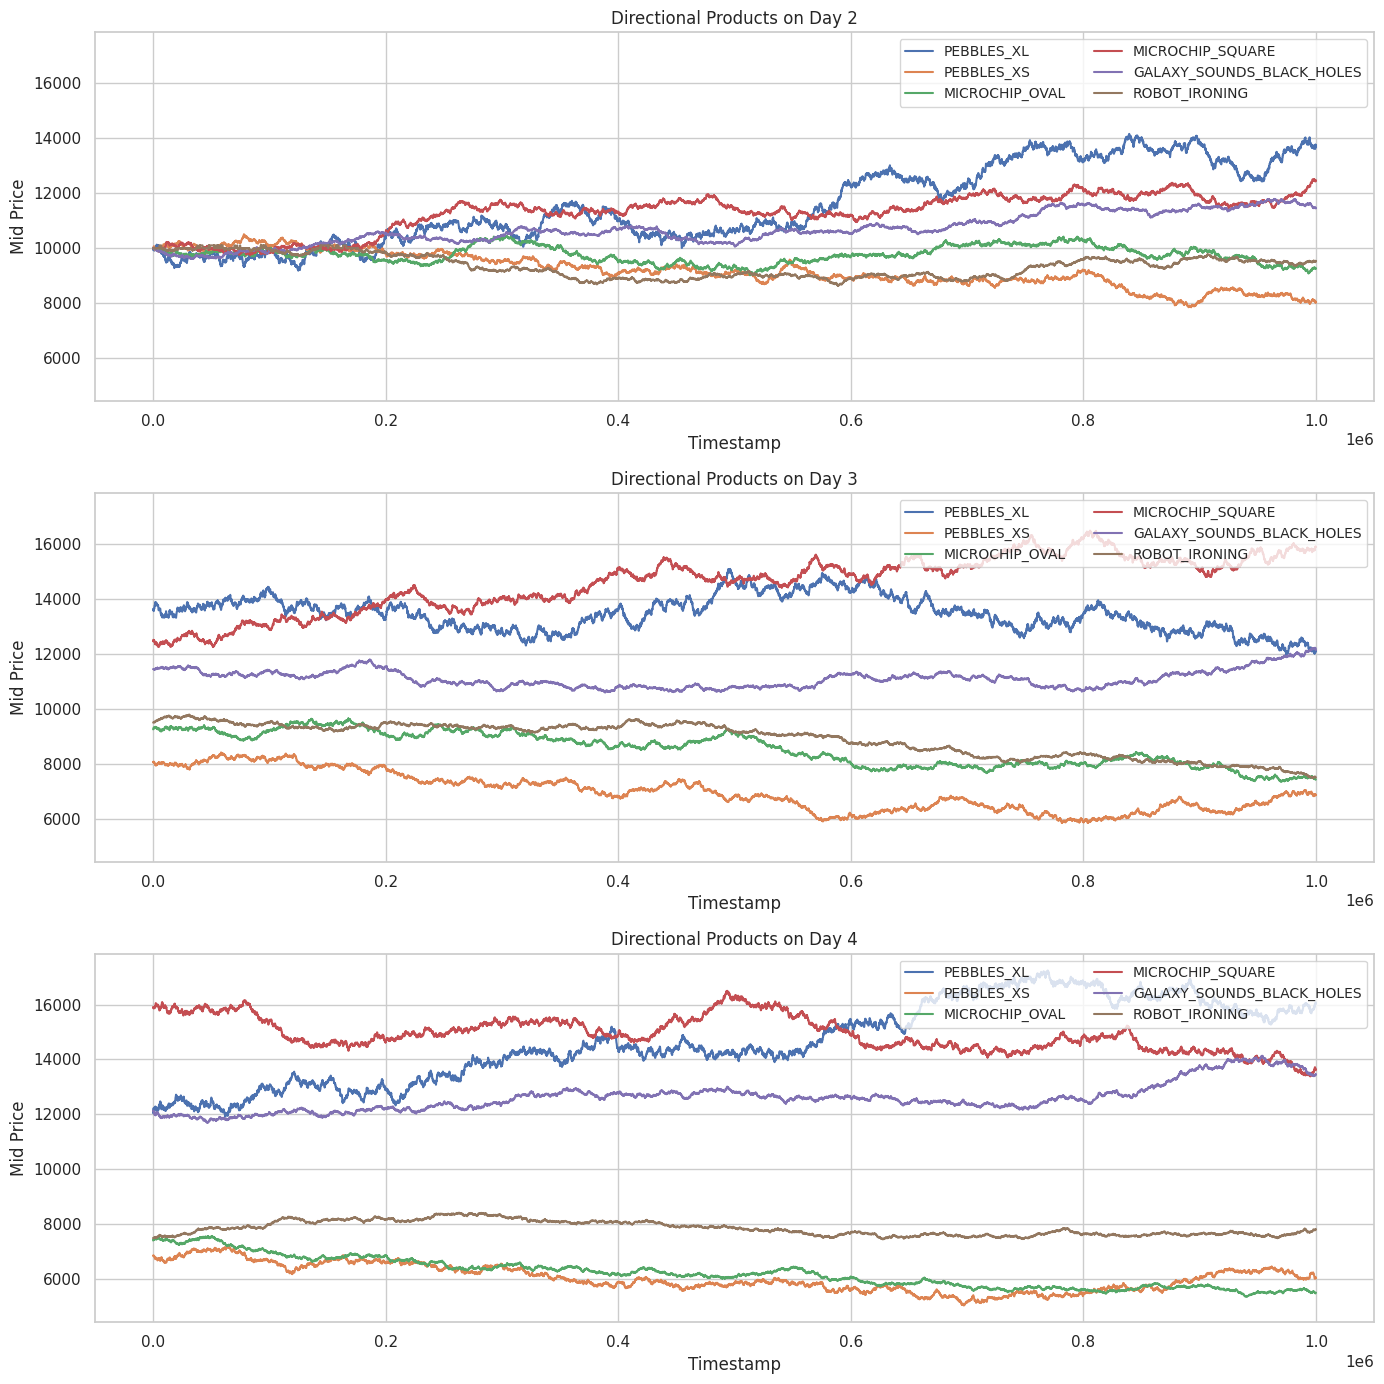

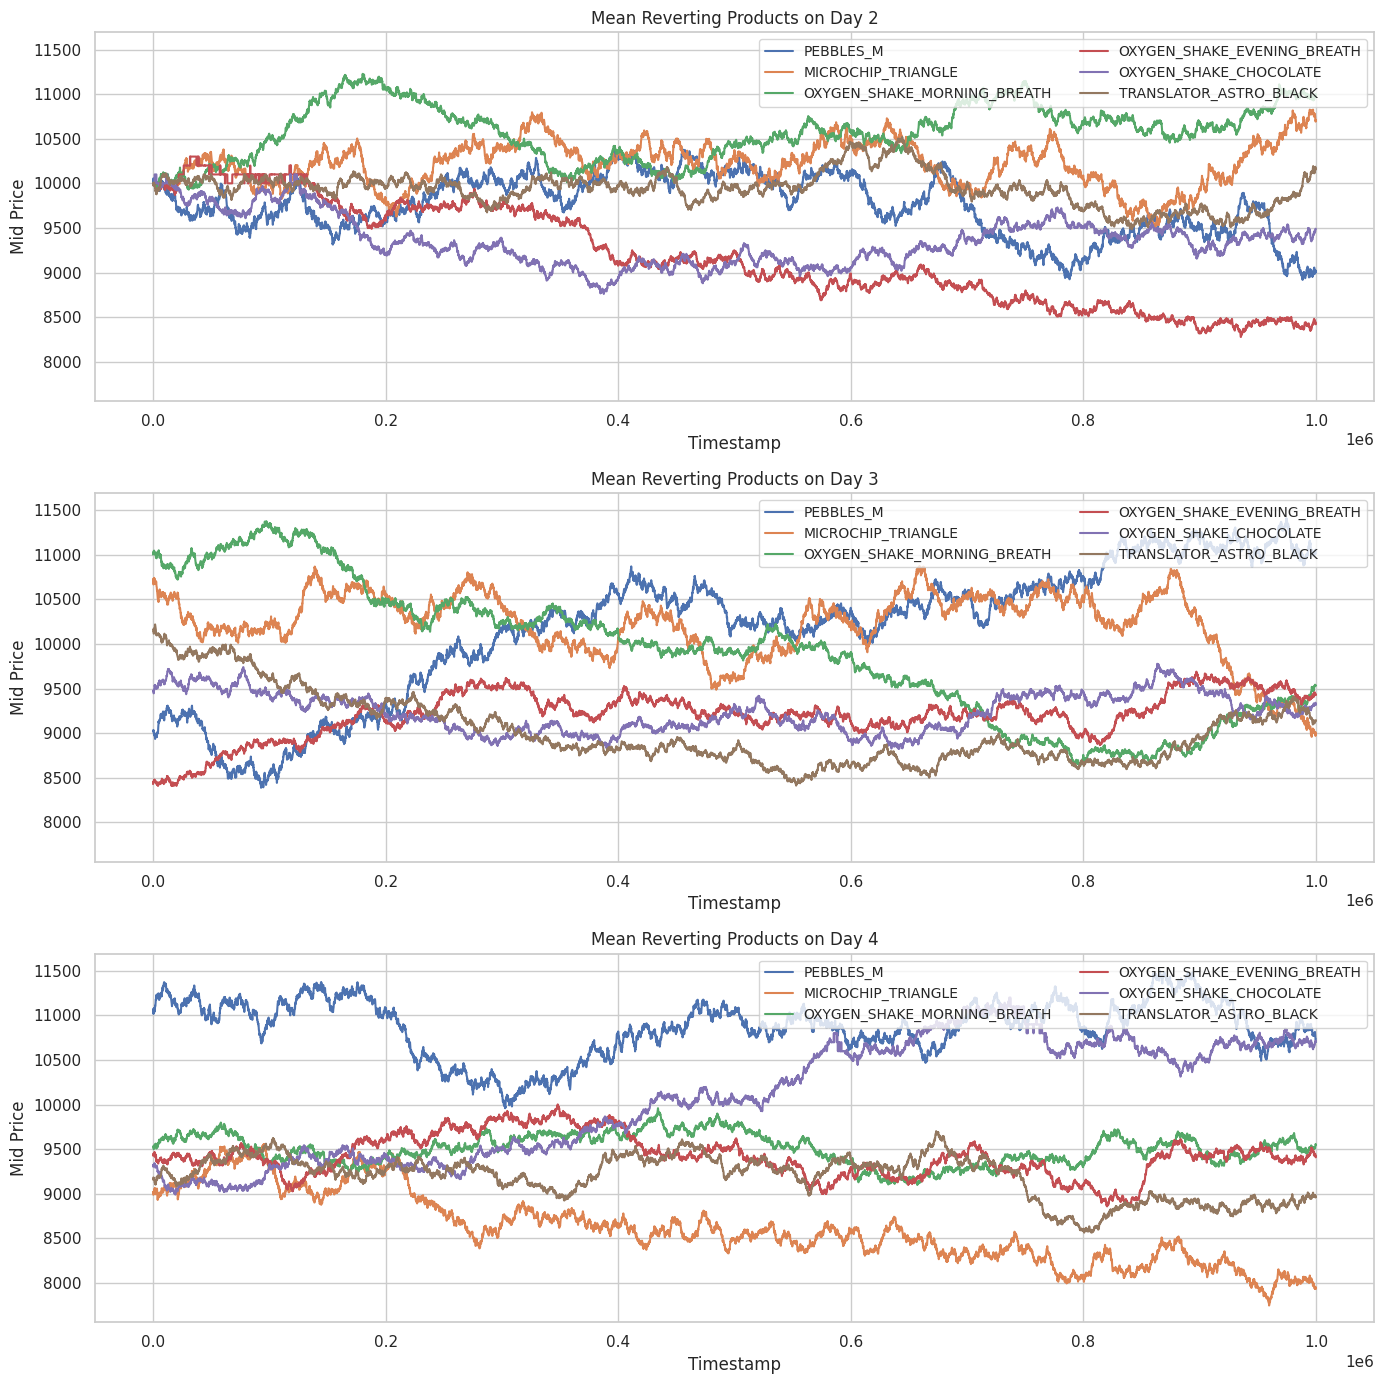

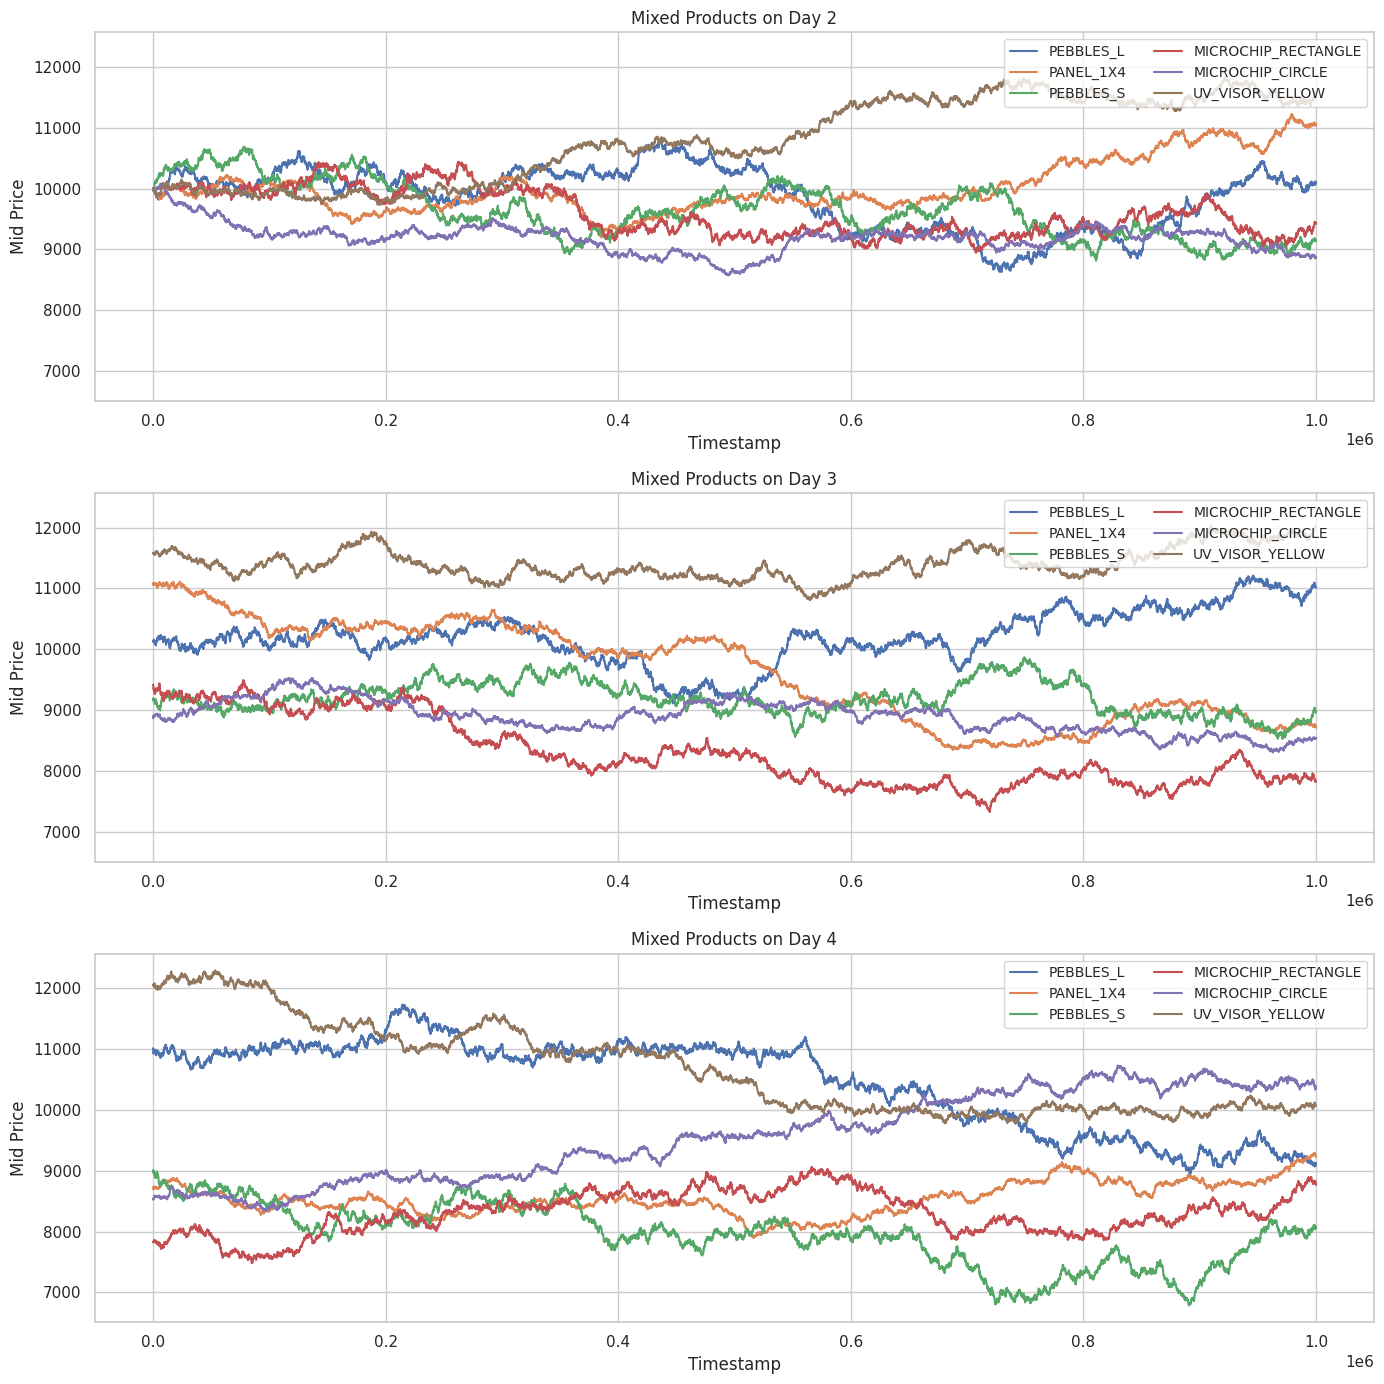

In [23]:
# Plot representative behavior groups using product-level labels.
for behavior in ["directional", "mean_reverting", "mixed"]:
    subset = product_summary[product_summary["behavior"] == behavior]
    if subset.empty:
        continue
    sample = subset.sort_values(by="mean_price_range", ascending=False).head(6)
    fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharey=True)
    for idx, day in enumerate(sorted(price_files)):
        ax = axes[idx]
        day_products = sample["product"].tolist()
        filtered = all_prices[(all_prices["day"] == day) & (all_prices["product"].isin(day_products))]
        if filtered.empty:
            ax.text(0.5, 0.5, f"No {behavior} products on Day {day}", ha="center", va="center", fontsize=14)
        else:
            for product in day_products:
                product_df = filtered[filtered["product"] == product].sort_values("timestamp")
                if not product_df.empty:
                    ax.plot(product_df["timestamp"], product_df["mid_price"], label=product)
            ax.legend(loc="upper right", fontsize="small", ncol=2)
        ax.set_title(f"{behavior.replace('_', ' ').title()} Products on Day {day}")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Mid Price")
    plt.tight_layout()
    plt.show()

## Notes

- Products are grouped by their estimated time-series behavior using trend and mean-reversion features.
- `directional` products show a persistent drift or strong trend over the day.
- `mean_reverting` products show weaker trend strength and indicators that prices oscillate around their average.
- `mixed` products are intermediates where neither signal is dominant.
- These grouped behaviors can help select strategy families for different products: trend-following for directional names, mean-reversion for oscillating names, and hybrid approaches for mixed names.